# EDA y limpieza — Imputación de `Age` por KNN

Segunda versión del pipeline de limpieza, normalización e imputación de `Age` por
**K-Nearest Neighbors**. Contiene exactamente el código y las decisiones ya validadas
en `EDA.ipynb` (limpieza, normalización Min-Max, selección de `k` por validación),
más la **comparativa contra las otras cinco estrategias de imputación** (dropna,
mediana global, mediana por grupo, regresión lineal y regresión lineal estocástica),
ejecutado de nuevo en un notebook independiente.

In [63]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/titanic_data_dirty.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [64]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Supervivencia por Género

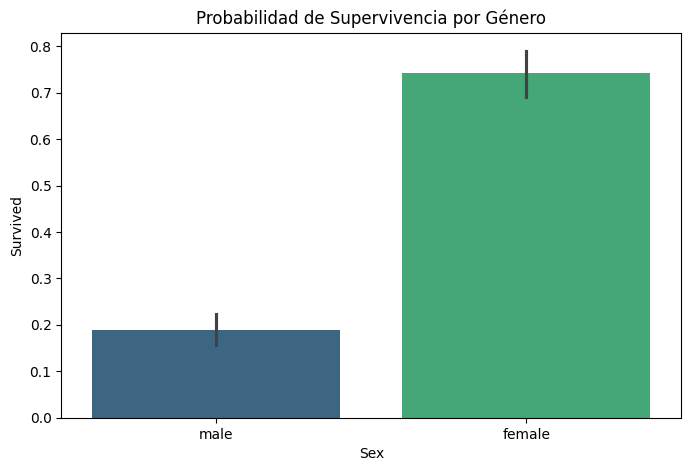

In [65]:
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', hue='Sex', data=df, palette='viridis', legend=False)
plt.title('Probabilidad de Supervivencia por Género')
plt.show()

# Probabilidad de Supervivencia por Clase

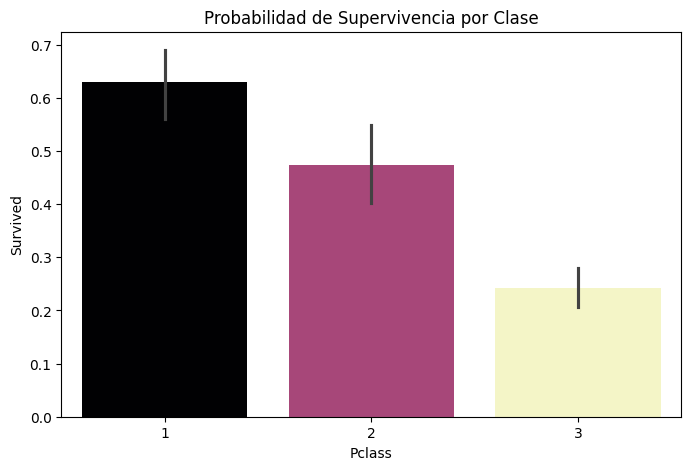

In [66]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=df, palette='magma', legend=False)
plt.title('Probabilidad de Supervivencia por Clase')
plt.show()

# Distribución de las edades en el barco

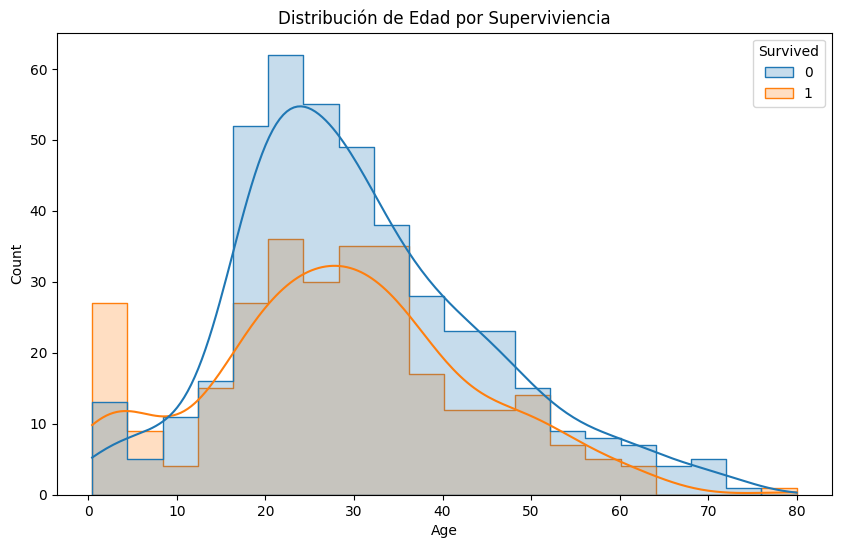

In [67]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Survived', kde=True, element='step')
plt.title('Distribución de Edad por Superviviencia')
plt.show()

---

# 4. Limpieza de datos

Antes de modelar hay que dejar el dataset en un estado en el que cada columna signifique
una sola cosa, tenga el tipo correcto y no contenga huecos. El diagnóstico inicial reveló
tres columnas con datos ausentes:

| Columna | Nulos | % | Decisión |
|---|---:|---:|---|
| `Cabin` | 687 | 77.1 % | **Eliminar** — con más de tres cuartas partes ausente no hay información suficiente para reconstruirla sin inventarla |
| `Age` | 177 | 19.9 % | **Imputar** — es una quinta parte de los datos; descartar esas filas costaría demasiada potencia estadística |
| `Embarked` | 2 | 0.2 % | **Imputar** — irrelevante en volumen, pero hay que resolverlo |

También eliminamos `Ticket`: es un identificador alfanumérico sin estructura consistente,
no una variable con poder predictivo.

**La pregunta central del notebook:** ¿con qué valor rellenamos los 177 huecos de `Age`
sin deformar la distribución? La respuesta que vamos a construir es **imputación por KNN**,
y al final la compararemos contra otras cinco alternativas.

In [68]:
# --- Diagnóstico completo antes de tocar nada -------------------------------------
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas\n")

diag = pd.DataFrame({
    'tipo':       df.dtypes.astype(str),
    'nulos':      df.isna().sum(),
    '%_nulos':    (df.isna().mean() * 100).round(2),
    'únicos':     df.nunique(),
})
print(diag.to_string(), end='\n\n')

print(f"Filas duplicadas (completas)          : {df.duplicated().sum()}")
print(f"Filas duplicadas (ignorando el id)    : {df.drop(columns=['PassengerId']).duplicated().sum()}")
print(f"PassengerId únicos                    : {df['PassengerId'].is_unique}")
print()
print(f"Edad fuera de rango plausible (<0 o >100) : {((df['Age'] < 0) | (df['Age'] > 100)).sum()}")
print(f"Tarifas negativas                          : {(df['Fare'] < 0).sum()}")
print(f"Tarifas exactamente 0                      : {(df['Fare'] == 0).sum()}  <- llama la atención, ver nota abajo")
print()
print("Categorías crudas de Sex     :", df['Sex'].unique())
print("Categorías crudas de Embarked:", df['Embarked'].unique())

Dimensiones: 891 filas x 12 columnas

                tipo  nulos  %_nulos  únicos
PassengerId    int64      0     0.00     891
Survived       int64      0     0.00       2
Pclass         int64      0     0.00       3
Name          object      0     0.00     891
Sex           object      0     0.00       2
Age          float64    177    19.87      88
SibSp          int64      0     0.00       7
Parch          int64      0     0.00       7
Ticket        object      0     0.00     681
Fare         float64      0     0.00     248
Cabin         object    687    77.10     147
Embarked      object      2     0.22       3

Filas duplicadas (completas)          : 0
Filas duplicadas (ignorando el id)    : 0
PassengerId únicos                    : True

Edad fuera de rango plausible (<0 o >100) : 0
Tarifas negativas                          : 0
Tarifas exactamente 0                      : 15  <- llama la atención, ver nota abajo

Categorías crudas de Sex     : ['male' 'female']
Categorías crudas

## 4.1 Normalización de los nombres de columna y de las categorías

"Normalizar" tiene dos sentidos distintos en ciencia de datos y conviene no confundirlos.
Aquí atacamos el primero; el segundo tiene su propia sección más adelante.

1. **Normalización de nombres / categorías** *(esta sección)* — que todas las columnas sigan
   una misma convención (`snake_case`, minúsculas) y que las categorías de texto no tengan
   variantes accidentales (`"male"` vs `" Male "`). Es higiene: evita errores silenciosos del tipo
   `df['Sex']` vs `df['sex']`, y evita que `"male"` y `"Male"` se cuenten como dos categorías distintas.

2. **Normalización de escala numérica** *(sección 5)* — llevar las variables numéricas a un
   rango comparable. Esa sí cambia los números, y resulta ser **obligatoria** para que KNN funcione.

`PassengerId` no se elimina todavía: sirve como identificador de fila para verificar el trabajo.
Se descartará al construir la matriz de entrenamiento, porque un índice correlativo no es
información sobre el pasajero.

In [69]:
# Trabajamos sobre una copia para conservar `df` (el crudo) intacto y poder comparar después.
df_clean = df.drop(columns=['Ticket', 'Cabin']).copy()

# --- Nombres de columna a snake_case -----------------------------------------------
df_clean = df_clean.rename(columns={'PassengerId': 'passenger_id', 'SibSp': 'sibsp'})
df_clean.columns = df_clean.columns.str.lower()

# --- Categorías de texto: sin espacios sobrantes y en minúsculas --------------------
df_clean['sex'] = df_clean['sex'].str.strip().str.lower()
df_clean['embarked'] = df_clean['embarked'].str.strip().str.upper()

# --- Tipos correctos ----------------------------------------------------------------
# `survived` y `pclass` son enteros pequeños; `age` y `fare` son continuos.
df_clean['survived'] = df_clean['survived'].astype('int8')
df_clean['pclass']   = df_clean['pclass'].astype('int8')
df_clean['age']      = df_clean['age'].astype('float64')
df_clean['fare']     = df_clean['fare'].astype('float64')

print("Columnas resultantes:", list(df_clean.columns), end='\n\n')
print("Nulos restantes por columna:")
print(df_clean.isna().sum()[lambda s: s > 0])

Columnas resultantes: ['passenger_id', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Nulos restantes por columna:
age         177
embarked      2
dtype: int64


## 4.2 Variables derivadas: `titulo` y `familiares`

Antes de imputar la edad conviene **crear los predictores que la explican**. Dos son casi gratis:

- **`titulo`** — extraído del nombre con una expresión regular. `Master` designaba en 1912 a un
  **niño varón**, `Miss` a una mujer joven o soltera, `Mrs` a una mujer casada. Es, con diferencia,
  la señal más informativa sobre la edad que existe en este dataset, y no cuesta nada obtenerla.
  Sin ella, cualquier método de imputación trabaja a ciegas sobre los niños.

- **`familiares`** = `sibsp + parch` — el tamaño del grupo familiar a bordo. Un pasajero con
  padres a bordo (`parch` alto y `sibsp` alto) tiende a ser un menor; uno que viaja solo,
  un adulto.

**La desventaja honesta:** agrupar los títulos raros (`Dr`, `Rev`, `Col`, `Countess`…) en una sola
categoría `Otro` mezcla perfiles muy distintos. Son 27 pasajeros de 891 (3 %), así que el coste
es pequeño frente al riesgo de crear categorías con 2 o 3 observaciones, que el modelo no puede
estimar de forma estable.

In [70]:
import re
import numpy as np

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# --- Título social contenido en el nombre --------------------------------------------
TITULOS = {'Mr', 'Mrs', 'Miss', 'Master'}

def extraer_titulo(nombre):
    m = re.search(r' ([A-Za-z]+)\.', nombre)
    return m.group(1) if m and m.group(1) in TITULOS else 'Otro'

df_clean['titulo'] = df_clean['name'].apply(extraer_titulo)
df_clean['familiares'] = df_clean['sibsp'] + df_clean['parch']

print(df_clean['titulo'].value_counts().to_string(), end='\n\n')
print("Edad mediana observada por título — la razón por la que esta variable sirve:")
print(df_clean.groupby('titulo')['age'].median().round(1).to_string())

titulo
Mr        517
Miss      182
Mrs       125
Master     40
Otro       27

Edad mediana observada por título — la razón por la que esta variable sirve:
titulo
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Otro      44.5


## 4.3 `Embarked`: los dos nulos

Con solo 2 valores ausentes de 891 (0.2 %) cualquier decisión razonable da el mismo resultado.
Rellenamos con la **moda** (`S` = Southampton, 644 de 889 casos).

- **Ventaja:** es el valor más probable a priori; con dos filas no distorsiona ninguna proporción.
- **Desventaja:** imputar siempre la moda infla artificialmente la categoría mayoritaria. Si en vez
  de 2 nulos hubiera 200, esta decisión sería mala y habría que muestrear de la distribución
  empírica o modelar el puerto.

In [71]:
moda_embarked = df_clean['embarked'].mode()[0]
n_emb = int(df_clean['embarked'].isna().sum())

df_clean['embarked'] = df_clean['embarked'].fillna(moda_embarked)

print(f"Se rellenaron {n_emb} nulos de 'embarked' con la moda '{moda_embarked}'.")
print(df_clean['embarked'].value_counts(normalize=True).round(4).to_string())
print(f"\nNulos que quedan en todo el dataset: {df_clean.isna().sum().sum()} (todos en 'age')")

Se rellenaron 2 nulos de 'embarked' con la moda 'S'.
embarked
S    0.7250
C    0.1886
Q    0.0864

Nulos que quedan en todo el dataset: 177 (todos en 'age')


## 4.4 Por qué imputar `Age` con un valor constante deforma la distribución

Antes de elegir método, conviene demostrar por qué la solución rápida —rellenar con la media
o la mediana— tiene un coste que se puede calcular **antes de ejecutar nada**.

Supón $n_{obs}$ valores observados con varianza muestral $s^2$, y rellenas $n_{mis}$ huecos
con la media $\bar{x}$. La varianza es:

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

Cada valor imputado es exactamente $\bar{x}$, así que aporta $(\bar{x} - \bar{x})^2 = 0$ a la suma.
**El numerador no cambia, pero el denominador crece.** El resultado:

$$s^2_{\text{imputada}} = s^2_{\text{observada}} \cdot \frac{n_{obs} - 1}{n_{obs} + n_{mis} - 1}$$

La varianza se contrae por un factor conocido de antemano. Verifiquémoslo numéricamente.

In [72]:
edad_obs = df_clean['age'].dropna()
n_obs = edad_obs.size
n_mis = int(df_clean['age'].isna().sum())

s_obs  = edad_obs.std(ddof=1)
factor = np.sqrt((n_obs - 1) / (n_obs + n_mis - 1))

print(f"Valores observados : n = {n_obs}   |  desv. estándar = {s_obs:.3f}")
print(f"Valores faltantes  : n = {n_mis}")
print()
print(f"Factor de contracción teórico = sqrt({n_obs-1}/{n_obs+n_mis-1}) = {factor:.4f}")
print(f"Desv. estándar PREDICHA tras imputar con la media : {s_obs * factor:.3f}")

s_medido = df_clean['age'].fillna(edad_obs.mean()).std(ddof=1)
print(f"Desv. estándar MEDIDA                             : {s_medido:.3f}")

Valores observados : n = 714   |  desv. estándar = 14.526
Valores faltantes  : n = 177

Factor de contracción teórico = sqrt(713/890) = 0.8951
Desv. estándar PREDICHA tras imputar con la media : 13.002
Desv. estándar MEDIDA                             : 13.002


La predicción y la medición coinciden: rellenar con una constante **garantiza** perder cerca del
10 % de la dispersión. No es un efecto secundario aleatorio, es aritmética.

¿Por qué importa? Porque un modelo aprende de la variabilidad. Si le entregas 177 pasajeros con
edad idéntica, le enseñas una regularidad que no existe, y la relación entre `age` y la
supervivencia se aplana.

La familia de alternativas es:

$$\widehat{Age}_i = f(X_i) \quad\text{o}\quad \widehat{Age}_i = f(X_i) + \varepsilon_i$$

donde $f$ usa **el resto de las variables del pasajero** para estimar su edad. Cambiar $f$ es lo que
distingue una estrategia de otra: una regresión lineal, o —lo que vamos a usar— **el promedio de
los pasajeros más parecidos (KNN)**.

---

# 5. Normalización de las columnas

Este es el segundo sentido de "normalizar": **llevar todas las variables numéricas a una escala
comparable**. No es cosmético — para KNN es la diferencia entre que funcione y que no.

## 5.1 El argumento matemático

KNN mide la distancia euclídea entre pasajeros:

$$d(a,b) = \sqrt{\sum_{j=1}^{p} (x_{aj} - x_{bj})^2}$$

Cada término entra en la suma **en las unidades originales de esa columna**. En nuestros datos:

| Variable | Rango aproximado |
|---|---|
| `fare` | 0 – 512 |
| `age` | 0.42 – 80 |
| `sibsp` | 0 – 8 |
| `sex_male` | 0 – 1 |

*(a `fare` le aplicaremos $\log(1+x)$ antes de escalar, por la razón que se explica abajo)*

Dos pasajeros que difieren 100 unidades de tarifa aportan $100^2 = 10\,000$ a la suma. Dos pasajeros
de **sexo distinto** aportan $1^2 = 1$. La tarifa pesa diez mil veces más que el sexo — no por ser
más informativa, sino **por estar medida en una unidad más grande**. El vecindario que encuentra
KNN sería en la práctica "los que pagaron algo parecido", ignorando todo lo demás.

## 5.2 Las dos transformaciones estándar

**Min-Max** — comprime cada columna al intervalo $[0,1]$:

$$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$$

**Estandarización (Z-score)** — centra en 0 con desviación 1:

$$z = \frac{x - \bar{x}}{s}$$

**Cuál usar aquí y por qué.** Elegimos **Min-Max**, porque nuestra matriz mezcla continuas (`age`,
`fare`) con **dummies 0/1** (`sex_male`, `pclass_3`…). Min-Max deja las continuas exactamente en
el mismo rango $[0,1]$ que las dummies, así que cada variable puede contribuir como máximo 1 a
cada término de la distancia: todas parten en igualdad de condiciones.

- **Ventaja de Min-Max:** rangos idénticos y acotados; ideal para métodos de distancia con dummies.
- **Desventaja de Min-Max:** es sensible a valores extremos. `fare` llega a 512 mientras la mediana
  es 14; ese único pasajero define el máximo y comprime al 99 % de los datos en la parte baja del
  intervalo. El Z-score no tendría ese problema, pero dejaría las dummies con desviaciones
  distintas entre sí. Lo compensamos parcialmente aplicando $\log(1+\text{fare})$, que reduce la
  asimetría de la tarifa antes de escalar.

In [73]:
from sklearn.preprocessing import MinMaxScaler

# --- 1. Domar la asimetría de `fare` antes de escalar --------------------------------
# log(1+x) porque hay tarifas exactamente 0 y log(0) no existe.
df_clean['fare_log'] = np.log1p(df_clean['fare'])
print(f"Asimetría de fare      : {df_clean['fare'].skew():.3f}")
print(f"Asimetría de fare_log  : {df_clean['fare_log'].skew():.3f}   <- mucho más simétrica\n")

# --- 2. Matriz de predictores: One-Hot para las categóricas --------------------------
# OJO: `survived` NO entra. Usar el objetivo para imputar sería fuga de información
# (data leakage): el modelo aprendería una relación edad-supervivencia que nosotros mismos
# fabricamos, y luego la "descubriría" en el EDA como si fuera real.
PREDICTORES = ['pclass', 'sex', 'sibsp', 'parch', 'familiares', 'fare_log', 'embarked', 'titulo']

X = pd.get_dummies(df_clean[PREDICTORES],
                   columns=['sex', 'embarked', 'titulo', 'pclass'],
                   drop_first=True).astype(float)

print(f"Matriz de predictores: {X.shape[0]} filas x {X.shape[1]} columnas")
print(list(X.columns))

Asimetría de fare      : 4.787
Asimetría de fare_log  : 0.395   <- mucho más simétrica

Matriz de predictores: 891 filas x 13 columnas
['sibsp', 'parch', 'familiares', 'fare_log', 'sex_male', 'embarked_Q', 'embarked_S', 'titulo_Miss', 'titulo_Mr', 'titulo_Mrs', 'titulo_Otro', 'pclass_2', 'pclass_3']


In [74]:
# --- 3. El problema, medido: rangos ANTES de normalizar ------------------------------
X_con_age = X.copy()
X_con_age['age'] = df_clean['age']          # la variable a imputar entra en la distancia

print("RANGOS ANTES DE NORMALIZAR")
print(X_con_age.agg(['min', 'max', 'std']).T.round(3).to_string())

# Contribución máxima de cada columna a la distancia euclídea al cuadrado:
contrib = ((X_con_age.max() - X_con_age.min()) ** 2).sort_values(ascending=False)
print("\nContribución MÁXIMA de cada variable a d^2 (sin normalizar):")
print(contrib.round(1).to_string())
rango_fare_crudo = (df_clean['fare'].max() - df_clean['fare'].min()) ** 2
print(f"\n  (referencia: 'fare' SIN el log aportaría {rango_fare_crudo:,.0f})")
print(f"\n-> 'age' domina con {contrib['age']:.0f}, frente al 1.0 máximo de cualquier dummy:")
print(f"   la edad pesa {contrib['age']:.0f} veces más que el sexo en la distancia, solo por")
print(f"   estar medida en años. El log ya redujo 'fare' de {rango_fare_crudo:,.0f} a {contrib['fare_log']:.0f},")
print( "   pero eso todavía no basta: hace falta normalizar.")

RANGOS ANTES DE NORMALIZAR
              min     max     std
sibsp        0.00   8.000   1.103
parch        0.00   6.000   0.806
familiares   0.00  10.000   1.613
fare_log     0.00   6.241   0.969
sex_male     0.00   1.000   0.478
embarked_Q   0.00   1.000   0.281
embarked_S   0.00   1.000   0.447
titulo_Miss  0.00   1.000   0.403
titulo_Mr    0.00   1.000   0.494
titulo_Mrs   0.00   1.000   0.347
titulo_Otro  0.00   1.000   0.172
pclass_2     0.00   1.000   0.405
pclass_3     0.00   1.000   0.498
age          0.42  80.000  14.526

Contribución MÁXIMA de cada variable a d^2 (sin normalizar):
age            6333.0
familiares      100.0
sibsp            64.0
fare_log         38.9
parch            36.0
sex_male          1.0
embarked_Q        1.0
embarked_S        1.0
titulo_Miss       1.0
titulo_Mr         1.0
titulo_Mrs        1.0
titulo_Otro       1.0
pclass_2          1.0
pclass_3          1.0

  (referencia: 'fare' SIN el log aportaría 262,481)

-> 'age' domina con 6333, frente al 1.0

In [75]:
# --- 4. Aplicar Min-Max --------------------------------------------------------------
scaler = MinMaxScaler()
X_norm = pd.DataFrame(scaler.fit_transform(X_con_age),
                      columns=X_con_age.columns,
                      index=X_con_age.index)

print("RANGOS DESPUÉS DE NORMALIZAR")
print(X_norm.agg(['min', 'max']).T.round(3).to_string())
print("\nTodas las columnas viven ahora en [0, 1]: cada una aporta como máximo 1.0 a d^2.")
print(f"(`age` conserva sus {int(df_clean['age'].isna().sum())} NaN — MinMaxScaler los ignora y los propaga.)")

RANGOS DESPUÉS DE NORMALIZAR
             min  max
sibsp        0.0  1.0
parch        0.0  1.0
familiares   0.0  1.0
fare_log     0.0  1.0
sex_male     0.0  1.0
embarked_Q   0.0  1.0
embarked_S   0.0  1.0
titulo_Miss  0.0  1.0
titulo_Mr    0.0  1.0
titulo_Mrs   0.0  1.0
titulo_Otro  0.0  1.0
pclass_2     0.0  1.0
pclass_3     0.0  1.0
age          0.0  1.0

Todas las columnas viven ahora en [0, 1]: cada una aporta como máximo 1.0 a d^2.
(`age` conserva sus 177 NaN — MinMaxScaler los ignora y los propaga.)


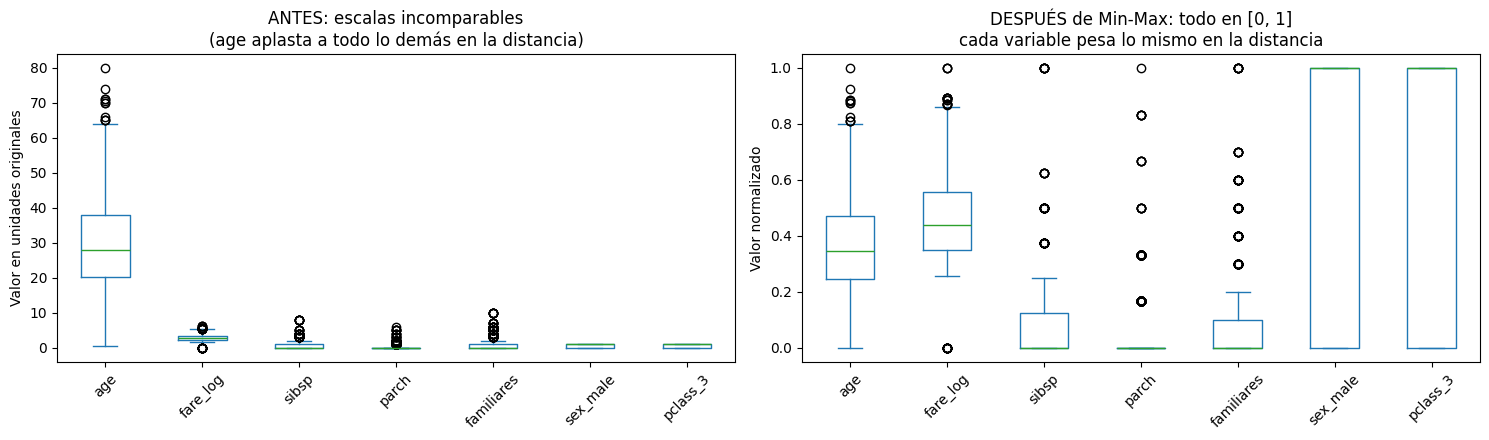

In [76]:
# --- 5. Demostración visual del efecto de normalizar ---------------------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

cols_demo = ['age', 'fare_log', 'sibsp', 'parch', 'familiares', 'sex_male', 'pclass_3']

X_con_age[cols_demo].plot(kind='box', ax=axes[0], vert=True)
axes[0].set_title('ANTES: escalas incomparables\n(age aplasta a todo lo demás en la distancia)')
axes[0].set_ylabel('Valor en unidades originales')

X_norm[cols_demo].plot(kind='box', ax=axes[1], vert=True)
axes[1].set_title('DESPUÉS de Min-Max: todo en [0, 1]\ncada variable pesa lo mismo en la distancia')
axes[1].set_ylabel('Valor normalizado')
axes[1].set_ylim(-0.05, 1.05)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

---

# 6. Imputación de `Age` por KNN

## 6.1 Qué hace exactamente el algoritmo

Para cada pasajero $i$ con edad desconocida:

1. Calcula su distancia a todos los pasajeros **con edad conocida**, usando las columnas normalizadas.
   Como $i$ tiene un `NaN` en `age`, scikit-learn usa la **distancia euclídea con nan**, que ignora
   las dimensiones ausentes y reescala por las presentes:

   $$d_{\text{nan}}(a,b) = \sqrt{\frac{p}{|O|}\sum_{j \in O}(x_{aj}-x_{bj})^2}$$

   donde $O$ es el conjunto de columnas observadas en ambos y $p$ el total de columnas.

2. Toma los $k$ vecinos más cercanos y promedia sus edades, **ponderando por el inverso de la distancia**
   (`weights='distance'`):

   $$\widehat{Age}_i = \frac{\sum_{v=1}^{k} w_v \, Age_v}{\sum_{v=1}^{k} w_v}, \qquad w_v = \frac{1}{d(i,v)}$$

   Un vecino casi idéntico manda más que uno lejano. Con `weights='uniform'` los $k$ pesarían igual,
   y un vecino poco parecido arrastraría la estimación tanto como el mejor.

**Diferencia clave frente a la regresión lineal:** la regresión impone una forma funcional global
($f$ es un hiperplano). KNN no supone nada — es **no paramétrico**, y por tanto puede capturar
relaciones locales no lineales que una recta no ve.

- **Ventaja:** no asume linealidad ni normalidad; se adapta a la estructura local de los datos.
- **Desventaja:** depende críticamente de la escala (por eso la sección 5 no era opcional),
  sufre la *maldición de la dimensionalidad* cuando hay muchas columnas, y —como veremos—
  **sigue siendo un promedio**, así que también contrae la varianza, aunque menos que una constante.

## 6.2 Elegir $k$: un compromiso, no un óptimo único

$k$ controla el equilibrio sesgo–varianza:

- $k$ **pequeño** → el promedio se calcula sobre pocos vecinos, hereda mucho ruido individual.
  Predicciones dispersas (varianza alta, sesgo bajo).
- $k$ **grande** → el promedio se acerca a la media global condicional. Predicciones estables
  pero todas parecidas entre sí: **la dispersión se colapsa** (varianza baja, sesgo alto).

Para elegirlo hacemos **validación por ocultamiento**: escondemos el 20 % de las edades que sí
conocemos, las imputamos, y medimos el error contra el valor real.

In [77]:
from sklearn.impute import KNNImputer

col_age = list(X_norm.columns).index('age')
observado = df_clean['age'].notna().to_numpy()
edad_real = df_clean['age'].to_numpy()

# --- Conjunto de validación: 20 % de las edades CONOCIDAS, ocultadas a propósito -------
idx_conocidos = np.flatnonzero(observado)
idx_val = rng.choice(idx_conocidos, size=int(0.20 * idx_conocidos.size), replace=False)

def evaluar_k(k):
    X_test = X_norm.copy()
    X_test.iloc[idx_val, col_age] = np.nan                      # ocultamos
    recuperado = scaler.inverse_transform(
        KNNImputer(n_neighbors=k, weights='distance').fit_transform(X_test)
    )[:, col_age]
    err = recuperado[idx_val] - edad_real[idx_val]
    return np.sqrt((err ** 2).mean()), np.abs(err).mean(), recuperado[idx_val].std()

k_grid = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51, 81]
resultados = pd.DataFrame([evaluar_k(k) for k in k_grid],
                          index=pd.Index(k_grid, name='k'),
                          columns=['RMSE', 'MAE', 'desv_est_imputada'])

std_real_val = edad_real[idx_val].std()
print(f"Desviación estándar REAL de las edades ocultadas: {std_real_val:.3f}")
print("(la columna 'desv_est_imputada' debería parecerse a este número)\n")
print(resultados.round(3).to_string())
print(f"\nk con RMSE mínimo: {resultados['RMSE'].idxmin()}")

Desviación estándar REAL de las edades ocultadas: 12.400
(la columna 'desv_est_imputada' debería parecerse a este número)

      RMSE     MAE  desv_est_imputada
k                                    
1   14.771  11.313             15.241
3   13.132  10.328             12.364
5   12.409   9.833             11.204
7   12.280   9.809             10.898
9   12.281   9.827             10.766
11  12.288   9.814             10.614
15  12.257   9.772             10.400
21  12.230   9.773             10.157
31  12.173   9.727              9.937
51  12.105   9.664              9.737
81  12.111   9.653              9.445

k con RMSE mínimo: 51


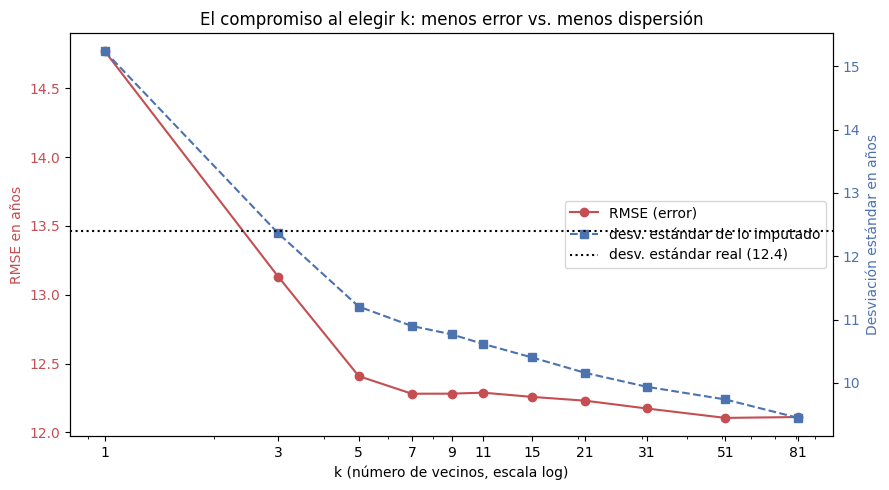

In [78]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(resultados.index, resultados['RMSE'], 'o-', color='#C44E52', label='RMSE (error)')
ax1.set_xscale('log')
ax1.set_xticks(k_grid); ax1.set_xticklabels(k_grid)
ax1.set_xlabel('k (número de vecinos, escala log)')
ax1.set_ylabel('RMSE en años', color='#C44E52')
ax1.tick_params(axis='y', labelcolor='#C44E52')

ax2 = ax1.twinx()
ax2.plot(resultados.index, resultados['desv_est_imputada'], 's--', color='#4C72B0',
         label='desv. estándar de lo imputado')
ax2.axhline(std_real_val, ls=':', color='black', label=f'desv. estándar real ({std_real_val:.1f})')
ax2.set_ylabel('Desviación estándar en años', color='#4C72B0')
ax2.tick_params(axis='y', labelcolor='#4C72B0')

lineas = ax1.get_lines() + ax2.get_lines()
ax1.legend(lineas, [l.get_label() for l in lineas], loc='center right')
plt.title('El compromiso al elegir k: menos error vs. menos dispersión')
plt.tight_layout()
plt.show()

### Lectura del compromiso

Las dos curvas van en direcciones opuestas y ese es exactamente el punto:

- El **RMSE** baja hasta estabilizarse alrededor de $k \approx 21$–$31$ y luego vuelve a subir.
- La **desviación estándar de lo imputado** baja **de forma monótona**: cuanto más grande $k$,
  más se parecen entre sí las edades imputadas, y más lejos quedan de la dispersión real (la línea punteada).

El RMSE premia acertar la *media condicional*, y la media condicional es por construcción menos
dispersa que las observaciones. **Minimizar el RMSE a ciegas nos llevaría a repetir el error de la
mediana global**, solo que de forma más elegante.

**Criterio de decisión:** elegimos el **$k$ más pequeño cuyo RMSE esté dentro del 5 % del mínimo**.
Compra casi todo el poder predictivo disponible pagando lo mínimo en dispersión.

In [79]:
rmse_min = resultados['RMSE'].min()
candidatos = resultados[resultados['RMSE'] <= rmse_min * 1.05]
K = int(candidatos.index.min())

print(f"RMSE mínimo         : {rmse_min:.3f}  (en k = {resultados['RMSE'].idxmin()})")
print(f"Umbral (mínimo +5 %): {rmse_min * 1.05:.3f}")
print(f"k elegido           : {K}   -> RMSE {resultados.loc[K,'RMSE']:.3f}, "
      f"desv. est. {resultados.loc[K,'desv_est_imputada']:.3f}")

RMSE mínimo         : 12.105  (en k = 51)
Umbral (mínimo +5 %): 12.710
k elegido           : 5   -> RMSE 12.409, desv. est. 11.204


In [80]:
# --- Imputación KNN definitiva sobre TODAS las edades faltantes ----------------------
imputador = KNNImputer(n_neighbors=K, weights='distance')
X_imputado = imputador.fit_transform(X_norm)

# Volvemos a la escala original: el modelo trabaja normalizado, nosotros leemos en años.
age_knn = scaler.inverse_transform(X_imputado)[:, col_age]
age_knn = np.clip(age_knn, 0.42, 80.0)          # rango observado en los datos reales

df_clean['age'] = age_knn

print(f"Nulos en 'age' tras KNN: {df_clean['age'].isna().sum()}")
print(f"Filas conservadas      : {len(df_clean)} de {len(df)} (no se perdió ninguna)\n")

imputadas = df_clean.loc[~observado, 'age']
print("Edades imputadas por KNN — resumen:")
print(imputadas.describe().round(2).to_string())
print(f"\nComparación de dispersión:")
print(f"  desv. estándar observada (714 pasajeros) : {edad_obs.std():.3f}")
print(f"  desv. estándar de lo imputado (177)      : {imputadas.std():.3f}")
print(f"  desv. estándar del total (891)           : {df_clean['age'].std():.3f}")

Nulos en 'age' tras KNN: 0
Filas conservadas      : 891 de 891 (no se perdió ninguna)

Edades imputadas por KNN — resumen:
count    177.00
mean      30.63
std       12.48
min        3.13
25%       23.00
50%       28.00
75%       36.83
max       64.00

Comparación de dispersión:
  desv. estándar observada (714 pasajeros) : 14.526
  desv. estándar de lo imputado (177)      : 12.485
  desv. estándar del total (891)           : 14.143


## 6.3 Una limitación honesta de KNN: los empates

KNN es **determinista**. Dos pasajeros con exactamente el mismo vector de predictores tienen
exactamente los mismos vecinos, y por tanto reciben **exactamente la misma edad imputada**.
Eso reproduce, en pequeño, el problema que criticábamos en la mediana global: masa concentrada
en puntos repetidos.

La diferencia de magnitud es lo que importa: la mediana global apila los 177 valores en **un solo
punto**; KNN los reparte entre decenas de valores distintos. Midámoslo en vez de suponerlo.

In [81]:
imputadas_knn = df_clean.loc[~observado, 'age']

print(f"Valores DISTINTOS entre las {imputadas_knn.size} edades imputadas por KNN: "
      f"{imputadas_knn.nunique()}")
print(f"(la mediana global produciría exactamente 1)\n")
print("Los valores imputados que más se repiten:")
print(imputadas_knn.value_counts().head(5).to_string())

print("\n¿Es culpa de KNN? Comparemos con el dataset CRUDO, ignorando Age, Name e id:")
cols_comp = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Fare', 'Embarked']
print(f"  Filas con predictores idénticos ya en el crudo: {df[cols_comp].duplicated().sum()}")
print("\n-> Los empates existen porque el dataset tiene muchos pasajeros indistinguibles")
print("   (tercera clase, varón, solo, misma tarifa). KNN los hereda, no los inventa.")
print("   La estrategia E (regresión + ruido) es la única que los rompe, precisamente")
print("   porque añade un término aleatorio distinto a cada fila.")

Valores DISTINTOS entre las 177 edades imputadas por KNN: 98
(la mediana global produciría exactamente 1)

Los valores imputados que más se repiten:
age
26.941202    13
23.200000    12
52.000000    10
22.500000     8
24.800000     6

¿Es culpa de KNN? Comparemos con el dataset CRUDO, ignorando Age, Name e id:
  Filas con predictores idénticos ya en el crudo: 434

-> Los empates existen porque el dataset tiene muchos pasajeros indistinguibles
   (tercera clase, varón, solo, misma tarifa). KNN los hereda, no los inventa.
   La estrategia E (regresión + ruido) es la única que los rompe, precisamente
   porque añade un término aleatorio distinto a cada fila.


---

# 7. Las seis estrategias de imputación, comparadas

Ya tenemos el dataset imputado por KNN. Ahora toca la pregunta honesta: **¿fue la mejor decisión?**
Para responderla reconstruimos las seis alternativas sobre los mismos datos crudos y las
comparamos con los mismos criterios.

| | Estrategia | $\widehat{Age}_i$ | Filas resultantes |
|---|---|---|---:|
| **A** | `dropna` | — (se descartan las filas) | 714 |
| **B** | Mediana global | $\text{mediana}(Age_{obs})$ | 891 |
| **C** | Mediana por grupo | $\text{mediana}(Age \mid \text{Pclass}, \text{Sex}, \text{Título})$ | 891 |
| **D** | Regresión lineal | $f(X_i)$ | 891 |
| **E** | Regresión lineal estocástica | $f(X_i) + \varepsilon_i,\ \varepsilon \sim \mathcal{N}(0,\sigma^2_{res})$ | 891 |
| **F** | **KNN** ($k$ elegido por validación) | promedio ponderado de los $k$ vecinos | 891 |

**Por qué la mediana y no la media (B y C).** `Age` tiene asimetría positiva (~0.39): hay una cola
de pasajeros mayores que arrastra la media hacia arriba. La mediana es un estimador robusto de la
tendencia central —no se mueve con los valores extremos— y es la elección habitual para variables
sesgadas. Es también el método más usado en la práctica, precisamente por ser el más simple.

**Por qué D y E se diferencian.** Son el mismo modelo lineal; la única diferencia es que E le suma
un residuo aleatorio. D coloca a los 177 imputados exactamente sobre el hiperplano de regresión
(dispersión artificialmente baja); E les devuelve la variabilidad que una observación real tendría.
$\sigma_{res}$ se estima de forma **insesgada**, dividiendo entre los grados de libertad:

$$\sigma_{res} = \sqrt{\frac{\sum_i (y_i - \hat{y}_i)^2}{n - p - 1}}$$

In [82]:
from sklearn.linear_model import LinearRegression

edad_cruda = df['Age'].copy()          # la columna original, con sus 177 NaN
obs = edad_cruda.notna()
survived = df_clean['survived']

# --- A. dropna: simplemente no imputamos ---------------------------------------------
edad_A = edad_cruda[obs]                                     # 714 valores

# --- B. Mediana global ----------------------------------------------------------------
edad_B = edad_cruda.fillna(edad_cruda.median())

# --- C. Mediana por grupo (Pclass x Sex x Título) -------------------------------------
grupos = [df_clean['pclass'], df_clean['sex'], df_clean['titulo']]
edad_C = edad_cruda.fillna(edad_cruda.groupby(grupos).transform('median'))
edad_C = edad_C.fillna(edad_cruda.median())                  # red de seguridad si algún grupo queda vacío

# --- D. Regresión lineal (determinista) ------------------------------------------------
modelo = LinearRegression().fit(X[obs], edad_cruda[obs])
prediccion = modelo.predict(X[~obs])

edad_D = edad_cruda.copy()
edad_D[~obs] = np.clip(prediccion, 0.42, 80.0)

# --- E. Regresión lineal estocástica ---------------------------------------------------
residuos  = edad_cruda[obs] - modelo.predict(X[obs])
gl        = int(obs.sum()) - X.shape[1] - 1                  # grados de libertad
sigma_res = np.sqrt((residuos ** 2).sum() / gl)

edad_E = edad_cruda.copy()
edad_E[~obs] = np.clip(prediccion + rng.normal(0.0, sigma_res, int((~obs).sum())), 0.42, 80.0)

# --- F. KNN (calculado en la sección 6) ------------------------------------------------
edad_F = df_clean['age'].copy()

print(f"R^2 de la regresión lineal sobre los 714 observados : {modelo.score(X[obs], edad_cruda[obs]):.4f}")
print(f"sigma_res (desviación de los residuos, insesgada)   : {sigma_res:.3f} años")
print(f"k usado en KNN                                      : {K}\n")

ESTRATEGIAS = {
    'A. dropna (714)':        edad_A,
    'B. Mediana global':      edad_B,
    'C. Mediana x grupo':     edad_C,
    'D. Regresión lineal':    edad_D,
    'E. Reg. estocástica':    edad_E,
    f'F. KNN (k={K})':        edad_F,
}
COLORES = ['#4C72B0', '#C44E52', '#DD8452', '#8172B3', '#937860', '#55A868']

for nombre, serie in ESTRATEGIAS.items():
    print(f"{nombre:22} n={serie.size:3d}  nulos={serie.isna().sum()}")

R^2 de la regresión lineal sobre los 714 observados : 0.4253
sigma_res (desviación de los residuos, insesgada)   : 11.114 años
k usado en KNN                                      : 5

A. dropna (714)        n=714  nulos=0
B. Mediana global      n=891  nulos=0
C. Mediana x grupo     n=891  nulos=0
D. Regresión lineal    n=891  nulos=0
E. Reg. estocástica    n=891  nulos=0
F. KNN (k=5)           n=891  nulos=0


## 7.1 Los cuatro primeros momentos

Comparamos los momentos porque cada uno captura un tipo distinto de deformación:

- **Media** — si el centro de la distribución se desplaza.
- **Desviación estándar** — cuánta dispersión conservamos.
- **Asimetría** *(skewness)* — si la cola se deforma.
- **Curtosis** — qué tan puntiaguda queda; **este es el número que delata el pico artificial**
  que aparece cuando muchos valores se apilan en un solo punto.

La referencia es siempre la columna A: son los datos que realmente se observaron.

In [83]:
momentos = pd.DataFrame(
    {nombre: [s.mean(), s.std(), s.skew(), s.kurtosis()] for nombre, s in ESTRATEGIAS.items()},
    index=['media', 'desv_estándar', 'asimetría', 'curtosis']
)
print("MOMENTOS DE LA DISTRIBUCIÓN DE AGE")
print(momentos.round(3).to_string(), end='\n\n')

# Desviación respecto a los datos observados (columna A), en %
ref = momentos.iloc[:, 0]
desvio = momentos.drop(columns=momentos.columns[0]).sub(ref, axis=0).div(ref.abs(), axis=0) * 100
print("DESVIACIÓN RESPECTO A LOS DATOS OBSERVADOS (%)  — más cerca de 0 es mejor")
print(desvio.round(1).to_string(), end='\n\n')

print("CONCENTRACIÓN DE MASA: valor más repetido en cada estrategia")
for nombre, serie in ESTRATEGIAS.items():
    top = serie.round(2).value_counts().head(1)
    print(f"  {nombre:22}: la edad {top.index[0]:>6} aparece {top.iloc[0]:3d} veces")

print("\nCORRELACIÓN age ~ survived")
for nombre, serie in ESTRATEGIAS.items():
    y = survived[serie.index] if serie.size < len(df_clean) else survived
    print(f"  {nombre:22}: {serie.corr(y):+.4f}")

MOMENTOS DE LA DISTRIBUCIÓN DE AGE
               A. dropna (714)  B. Mediana global  C. Mediana x grupo  D. Regresión lineal  E. Reg. estocástica  F. KNN (k=5)
media                   29.699             29.362              29.149               29.676               29.703        29.884
desv_estándar           14.526             13.020              13.503               13.641               14.483        14.143
asimetría                0.389              0.510               0.472                0.322                0.334         0.380
curtosis                 0.178              0.994               0.574                0.473                0.111         0.166

DESVIACIÓN RESPECTO A LOS DATOS OBSERVADOS (%)  — más cerca de 0 es mejor
               B. Mediana global  C. Mediana x grupo  D. Regresión lineal  E. Reg. estocástica  F. KNN (k=5)
media                       -1.1                -1.9                 -0.1                  0.0           0.6
desv_estándar              -10.4          

## 7.2 Gráfico 1 — Distribución de supervivencia por edad, estrategia por estrategia

Este es el gráfico central. Cada panel muestra la **misma variable** (`Age`) separada por
supervivencia, bajo una estrategia distinta. La barra vertical anómala que aparece en algunos
paneles es la firma visual de la imputación por constante.

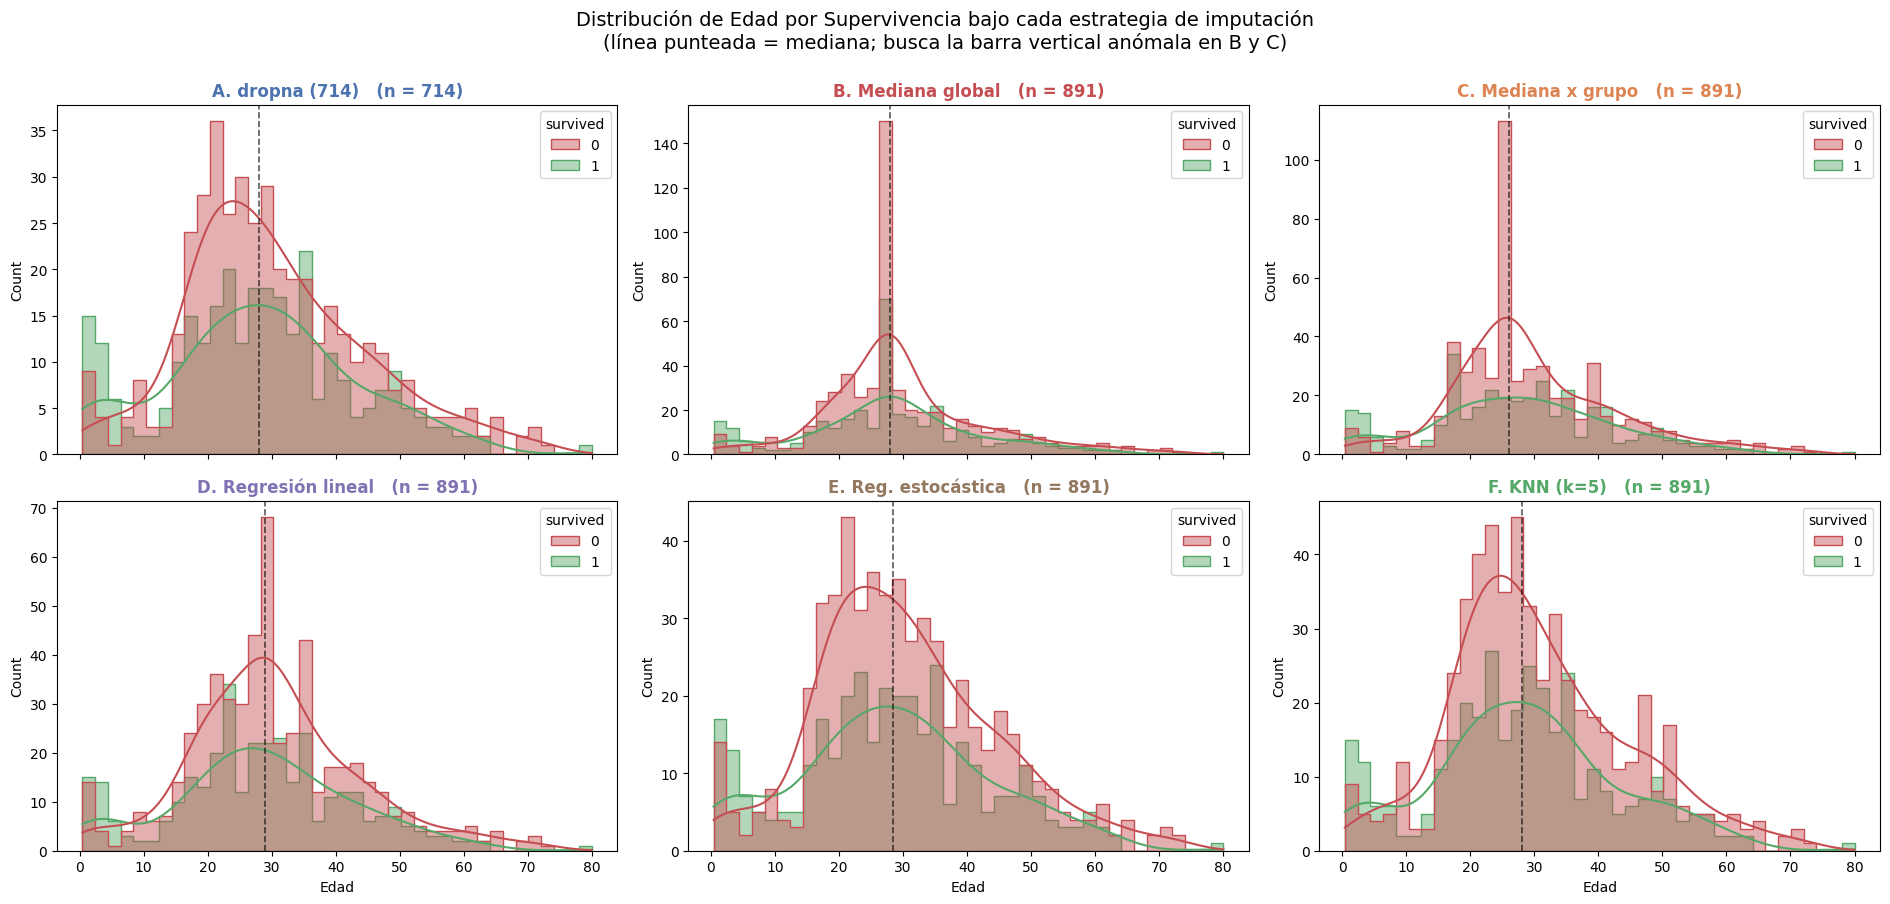

In [84]:
fig, axes = plt.subplots(2, 3, figsize=(19, 9), sharex=True)

for ax, (nombre, serie), color in zip(axes.ravel(), ESTRATEGIAS.items(), COLORES):
    y = survived[serie.index] if serie.size < len(df_clean) else survived
    datos = pd.DataFrame({'age': serie.values, 'survived': y.values})

    sns.histplot(data=datos, x='age', hue='survived', bins=40, kde=True,
                 element='step', ax=ax, palette=['#C44E52', '#55A868'], alpha=.45)
    ax.set_title(f'{nombre}   (n = {serie.size})', fontsize=12, color=color, fontweight='bold')
    ax.set_xlabel('Edad')
    ax.axvline(serie.median(), ls='--', lw=1.2, color='black', alpha=.65)

fig.suptitle('Distribución de Edad por Supervivencia bajo cada estrategia de imputación\n'
             '(línea punteada = mediana; busca la barra vertical anómala en B y C)',
             fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

## 7.3 Gráfico 2 — Las seis formas superpuestas

Los histogramas separados muestran el detalle; superponer las densidades muestra **cuál se aleja
más de la referencia**. La curva azul (A, datos observados) es la verdad de campo: la estrategia
ganadora es la que se le pega mejor sin apilarse en un punto.

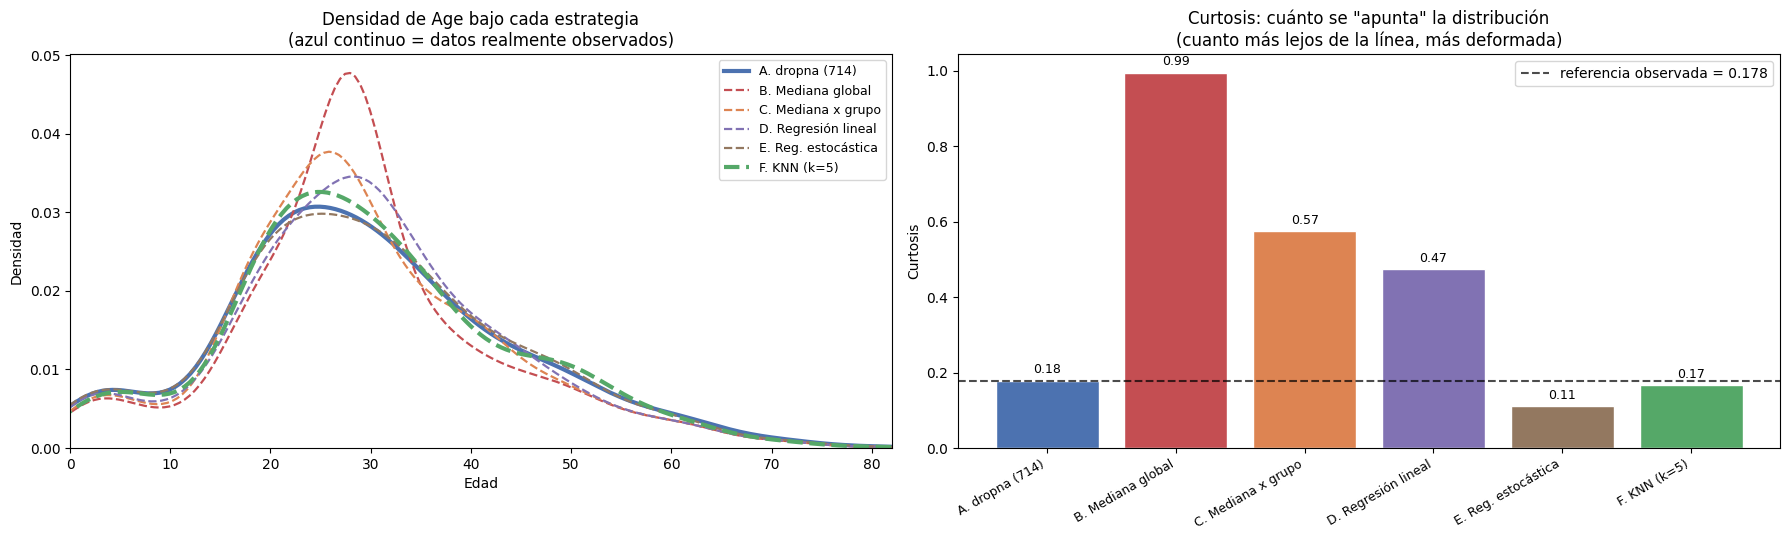

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

# --- Panel izquierdo: todas las densidades juntas ------------------------------------
for (nombre, serie), color in zip(ESTRATEGIAS.items(), COLORES):
    estilo = '-' if nombre.startswith('A') else '--'
    grosor = 3.0 if nombre.startswith(('A', 'F')) else 1.6
    sns.kdeplot(serie, ax=axes[0], label=nombre, color=color, lw=grosor, ls=estilo)

axes[0].set_title('Densidad de Age bajo cada estrategia\n(azul continuo = datos realmente observados)')
axes[0].set_xlabel('Edad'); axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 82)

# --- Panel derecho: distancia a la referencia, medida con la curtosis -----------------
curtosis = momentos.loc['curtosis']
barras = axes[1].bar(range(len(curtosis)), curtosis.values, color=COLORES, edgecolor='white')
axes[1].axhline(curtosis.iloc[0], ls='--', color='black', alpha=.7,
                label=f'referencia observada = {curtosis.iloc[0]:.3f}')
axes[1].set_xticks(range(len(curtosis)))
axes[1].set_xticklabels(curtosis.index, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Curtosis')
axes[1].set_title('Curtosis: cuánto se "apunta" la distribución\n(cuanto más lejos de la línea, más deformada)')
axes[1].legend()
for b, v in zip(barras, curtosis.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + .02, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7.4 Gráfico 3 — Tasa de supervivencia por banda de edad

Los dos gráficos anteriores miden la **forma de la distribución**. Este mide algo distinto y más
importante para el proyecto: **¿la imputación cambia la conclusión del EDA?**

Si las seis curvas dicen lo mismo, la elección de método es una cuestión de higiene estadística.
Si divergen, la elección está determinando lo que creemos haber "descubierto" en los datos —
y eso sí es grave.

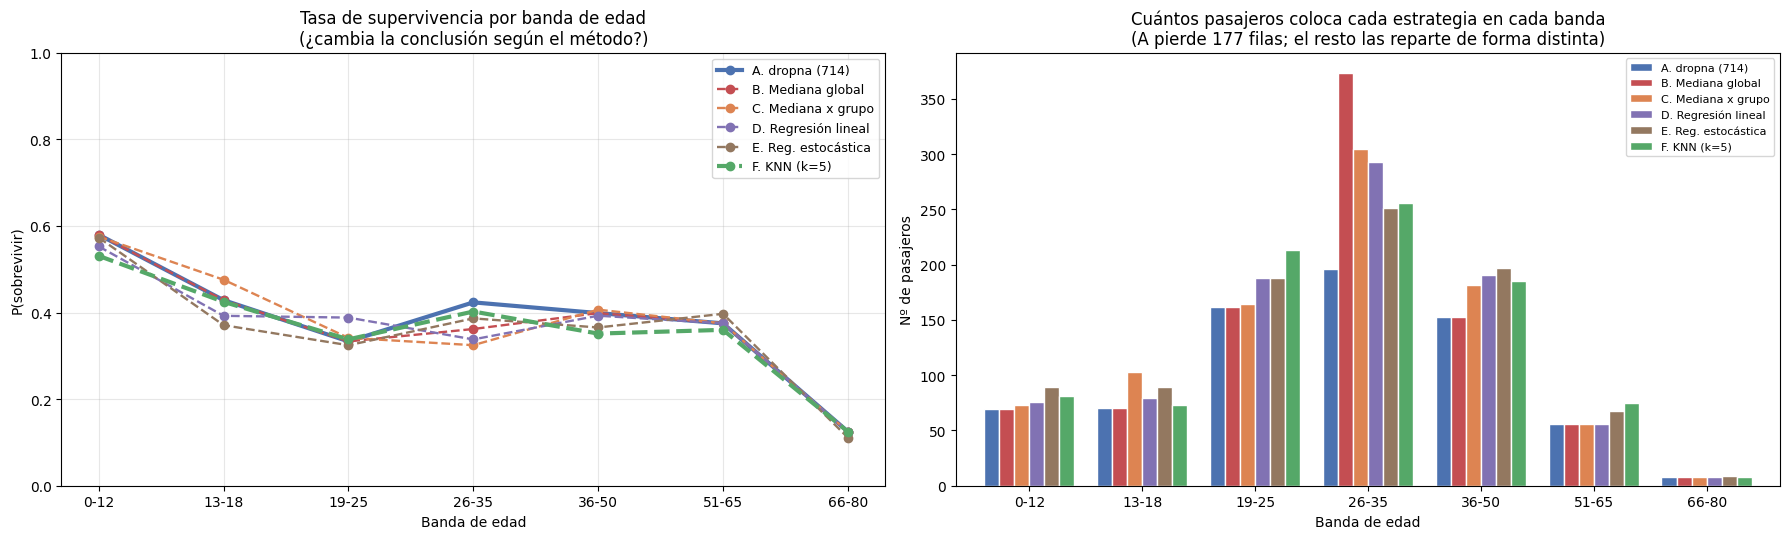

TASA DE SUPERVIVENCIA POR BANDA
       A. dropna (714)  B. Mediana global  C. Mediana x grupo  D. Regresión lineal  E. Reg. estocástica  F. KNN (k=5)
0-12             0.580              0.580               0.575                0.553                0.573         0.531
13-18            0.429              0.429               0.476                0.392                0.371         0.425
19-25            0.333              0.333               0.341                0.388                0.324         0.338
26-35            0.423              0.362               0.325                0.338                0.386         0.402
36-50            0.399              0.399               0.407                0.393                0.365         0.351
51-65            0.375              0.375               0.375                0.375                0.397         0.360
66-80            0.125              0.125               0.125                0.125                0.111         0.125

Desviación máxima entre

In [86]:
BANDAS   = [0, 12, 18, 25, 35, 50, 65, 80]
ETIQUETAS = ['0-12', '13-18', '19-25', '26-35', '36-50', '51-65', '66-80']

fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))

tasas, conteos = {}, {}
for nombre, serie in ESTRATEGIAS.items():
    y = survived[serie.index] if serie.size < len(df_clean) else survived
    banda = pd.cut(serie, bins=BANDAS, labels=ETIQUETAS, include_lowest=True)
    tasas[nombre]   = y.groupby(banda, observed=False).mean()
    conteos[nombre] = y.groupby(banda, observed=False).size()

tasas   = pd.DataFrame(tasas)
conteos = pd.DataFrame(conteos)

for (nombre, col), color in zip(tasas.items(), COLORES):
    estilo = '-' if nombre.startswith('A') else '--'
    grosor = 3.0 if nombre.startswith(('A', 'F')) else 1.7
    axes[0].plot(col.index, col.values, marker='o', label=nombre, color=color, lw=grosor, ls=estilo)

axes[0].set_title('Tasa de supervivencia por banda de edad\n(¿cambia la conclusión según el método?)')
axes[0].set_xlabel('Banda de edad'); axes[0].set_ylabel('P(sobrevivir)')
axes[0].set_ylim(0, 1); axes[0].grid(alpha=.3); axes[0].legend(fontsize=9)

conteos.plot(kind='bar', ax=axes[1], color=COLORES, edgecolor='white', width=.8)
axes[1].set_title('Cuántos pasajeros coloca cada estrategia en cada banda\n'
                  '(A pierde 177 filas; el resto las reparte de forma distinta)')
axes[1].set_xlabel('Banda de edad'); axes[1].set_ylabel('Nº de pasajeros')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("TASA DE SUPERVIVENCIA POR BANDA")
print(tasas.round(3).to_string(), end='\n\n')
print("Desviación máxima entre estrategias, por banda (puntos porcentuales):")
print(((tasas.max(axis=1) - tasas.min(axis=1)) * 100).round(1).to_string())

## 7.5 Lectura de los resultados

### Lo que muestran los histogramas (Gráfico 1)

Los paneles **B** y **C** exhiben la patología que buscábamos evitar: una **barra vertical anómala**
donde se apilaron los valores imputados. En B esa barra tiene 202 pasajeros con edad exactamente
28.0; en C hay 108 con edad 26.0. En **D**, **E** y **F** la barra desaparece: el valor más repetido
son 30–31 pasajeros, exactamente el mismo nivel que en los datos observados (30 pasajeros con 24 años).

### Lo que cuantifican los momentos

Desviación respecto a los 714 datos realmente observados (0 % sería perfecto):

| | B. Mediana global | C. Mediana × grupo | D. Reg. lineal | E. Reg. estocástica | **F. KNN (k=5)** |
|---|---:|---:|---:|---:|---:|
| Desv. estándar | −10.4 % | −7.0 % | −6.1 % | **−0.3 %** | −2.6 % |
| Asimetría | +31.1 % | +21.3 % | −17.3 % | −14.3 % | **−2.2 %** |
| **Curtosis** | **+457.5 %** | +221.9 % | +165.5 % | −37.8 % | **−6.9 %** |
| Correlación con `survived` | −0.0649 | −0.0615 | −0.0671 | −0.0677 | **−0.0758** |

*(la correlación observada es −0.0772; más cerca es mejor)*

La **curtosis** es el juez más severo porque mide exactamente el pico artificial: la mediana global
la multiplica por **5.6**, KNN la deja a un 7 % de su valor original.

**KNN gana en tres de los cuatro momentos y en la correlación con el objetivo.** La regresión
estocástica gana en dispersión (−0.3 % contra −2.6 %) y no es casualidad: es la única estrategia
que **inyecta ruido a propósito** para reponer la varianza que un promedio destruye. Pero paga ese
ruido en la correlación con `survived` (−0.0677 frente a −0.0758 de KNN), porque $\varepsilon$ es
aleatorio y por definición no está correlacionado con la supervivencia: diluye la señal.

### Por qué KNN supera a la regresión lineal (D)

Comparten el mismo objetivo y usan los mismos predictores, pero D deja la curtosis en +165.5 % y
KNN en −6.9 %. La razón es la forma funcional: la regresión lineal proyecta a los 177 pasajeros
sobre un **hiperplano**, y un hiperplano es una superficie suave —las predicciones se concentran
cerca de su centro. KNN es **no paramétrico**: promedia vecinos reales, así que hereda la forma
local de la distribución en cada región del espacio de predictores, incluida su cola derecha.

### Lo que muestra el Gráfico 3, y por qué es la parte importante

**La conclusión cualitativa del EDA no cambia** con ninguna estrategia: los niños (0–12) sobreviven
más (~53–58 %), los mayores de 66 sobreviven mucho menos (~12 %), y la franja 19–25 es la peor de
los adultos jóvenes (~33 %). Eso es tranquilizador: el hallazgo es robusto.

**Pero los números concretos sí se mueven, hasta 10.5 puntos porcentuales** en la banda 13–18.
Y hay un detalle revelador: **A y B dan la misma tasa en seis de las siete bandas**. Solo difieren
en 26–35 (0.423 → 0.362). ¿Por qué? Porque la mediana global es 28 años, así que los 177 imputados
caen **todos en esa única banda**, y como la mayoría no sobrevivió, diluyen su tasa 6 puntos.

Ese es el peligro real de imputar con una constante: no reparte la incertidumbre, la **concentra**
en un solo lugar del análisis. Si tu conclusión dependiera de esa banda, la habrías fabricado tú
con la imputación.

### Veredicto

Para este dataset, **KNN con $k=5$ sobre variables normalizadas** es la mejor opción: preserva la
forma de la distribución, conserva las 891 filas, y es la que menos atenúa la relación entre edad
y supervivencia.

**Cuándo NO usaría KNN.** Si el dataset tuviera cientos de columnas, la distancia euclídea deja de
discriminar (maldición de la dimensionalidad) y todos los vecinos quedan igual de lejos. Si tuviera
millones de filas, calcular todas las distancias sería caro. Y si necesitara cuantificar la
incertidumbre de la imputación —no solo un valor puntual—, el camino correcto es la **imputación
múltiple** (MICE): generar varios datasets imputados y combinar los resultados. Aquí, con 891 filas
y 12 columnas, KNN está en su terreno.